# 04. 承認薬recovery ベンチマーク: epitope reversal vs transcriptome reversal

**検証したい主張**：「各疾患について、承認薬を上位にランクする精度が、**epitope空間のsignature逆位** の方が
**通常のtranscriptome逆位** より遥かに高い」

**ベンチマーク**：
```
各疾患d: 全候補薬を reversal = -cos(薬, 疾患シグネチャ) で順位付け
         その疾患の承認薬が上位か = AUROC(承認薬 vs それ以外)
空間: ①transcriptome(L1000 landmark ~958) ②glycogene(385) ③epitope(52射影)
主張成立: ③ >> ① （疾患横断で平均AUROC）
```
**正直な前提**：前回エピトープの疾患マッチングは分離せず(p≈1)。勝つ保証はない。数字はそのまま報告する。

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from scipy.stats import wilcoxon
import snowflake.connector as sc
con = sc.connect(account='DUETMBM-LL33279', user='KOREEDA', role='ACCOUNTADMIN',
    warehouse='BIOINFORMATICS_XS', authenticator='SNOWFLAKE_JWT',
    private_key_file=os.path.expanduser('~/.ssh/snowflake_rsa_key.pem'))
cur=con.cursor()
def q(s):
    d=cur.execute(s).fetch_pandas_all(); d.columns=[c.lower() for c in d.columns]; return d
def ng(g): return str(g).upper().replace('-','_')
print('connected')

connected


## 1. 承認薬-疾患ペア／薬シグネチャ(transcriptome landmark + glycogene)／疾患シグネチャ

In [2]:
df_map=q('SELECT do_id,disease_name,pertname,drug_lc FROM RAW.CREEDS.VW_FIG3A_APPROVED_DRUG_MAP')
drugs=sorted(df_map['drug_lc'].unique())
inlist=','.join("'%s'"%d.replace("'","''") for d in drugs)
print(f"diseases={df_map['do_id'].nunique()} drugs={len(drugs)} pairs={len(df_map)}")

META={'sample_id','cell','pertname','pertid','dose','timepoint','pert_type'}
# ① transcriptome (landmark, 化合物平均)
dt=q(f'SELECT * FROM RAW.LINCS.L1000_LEVEL5_LANDMARK WHERE LOWER(PERTNAME) IN ({inlist})')
gc=[c for c in dt.columns if c not in META]
dt['lc']=dt['pertname'].str.lower()
drug_tx=dt.groupby('lc')[gc].mean(); drug_tx.columns=[ng(c) for c in drug_tx.columns]
print('drug_tx (transcriptome)', drug_tx.shape)

diseases=41 drugs=89 pairs=130


drug_tx (transcriptome) (89, 959)


In [3]:
# ② glycogene
METW={'value','canonical_smiles','cell','cmapid','compound_alias','dose','inchi_key','pertid','pertname','timepoint','sample_id'}
dg=q(f'SELECT * FROM RAW.LINCS.GLYCO_GENES_WIDE WHERE LOWER("pertname") IN ({inlist})')
gg=[c for c in dg.columns if c not in METW]
dg[gg]=dg[gg].apply(pd.to_numeric,errors='coerce'); dg['lc']=dg['pertname'].str.lower()
drug_gly=dg.groupby('lc')[gg].mean().fillna(0.0); drug_gly.columns=[ng(c) for c in drug_gly.columns]
print('drug_gly', drug_gly.shape)

# 疾患シグネチャ (CREEDS)
dd=q('''SELECT g.signature_id,g.gene,g.value,m.do_id FROM RAW.CREEDS.VW_HUMAN_DISEASE_GENES g
        JOIN RAW.CREEDS.DISEASE_SIGNATURES_META m USING(signature_id)''')
dd['gene']=dd['gene'].map(ng)
nsig=dd.groupby('do_id')['signature_id'].nunique()
ds=dd.groupby(['do_id','gene'])['value'].sum().reset_index()
ds['avg']=ds['value']/ds['do_id'].map(nsig)
dis_sig=ds.pivot(index='do_id',columns='gene',values='avg').fillna(0.0)
print('dis_sig', dis_sig.shape)

/var/folders/yb/qg8q9dxs50jft5_qv15b_2700000gn/T/ipykernel_47557/3753256523.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dg[gg]=dg[gg].apply(pd.to_numeric,errors='coerce'); dg['lc']=dg['pertname'].str.lower()


drug_gly (89, 385)


dis_sig (178, 18760)


## 2. epitope射影（薬・疾患を52エピトープへ）

In [4]:
steps=q('SELECT epitope_id,epitope_name,step_id,hgnc_symbol FROM RAW.GLYCOEPITOPE.EPITOPE_STEP_GENE')
steps['hgnc_symbol']=steps['hgnc_symbol'].map(ng)
ep_steps=steps.groupby(['epitope_id','epitope_name','step_id'])['hgnc_symbol'].apply(list).reset_index()
def project(sig):
    out={}
    for (i,nm),grp in ep_steps.groupby(['epitope_id','epitope_name']):
        sv=[sig[[g for g in r['hgnc_symbol'] if g in sig.columns]].max(axis=1)
            for _,r in grp.iterrows() if any(g in sig.columns for g in r['hgnc_symbol'])]
        if sv: out[nm]=pd.concat(sv,axis=1).min(axis=1)
    return pd.DataFrame(out)
drug_ep=project(drug_gly); dis_ep=project(dis_sig)
print('drug_ep',drug_ep.shape,' dis_ep',dis_ep.shape)

drug_ep (89, 52)  dis_ep (178, 48)


## 3. per-disease AUROC（承認薬recovery）を各空間で計算
reversal = -cos(薬,疾患)。疾患ごとに候補薬を並べ、承認薬が上位か(AUROC)。

In [5]:
def cos_mat(D, y):
    Dn=D/np.linalg.norm(D,axis=1,keepdims=True); yn=y/np.linalg.norm(y)
    return Dn@yn

def auroc_by_disease(D, Y):
    common=sorted(set(D.columns)&set(Y.columns))
    D2=D[common].dropna(); Y2=Y[common]
    D2=D2.loc[(np.linalg.norm(D2.values,axis=1)>0)]
    aucs={}
    for do in Y2.index:
        y=Y2.loc[do].values
        if np.linalg.norm(y)==0: continue
        rev=pd.Series(-cos_mat(D2.values,y), index=D2.index)  # 高い=逆位
        appr=set(df_map.loc[df_map.do_id==do,'drug_lc']) & set(D2.index)
        lab=np.array([1 if d in appr else 0 for d in D2.index])
        if lab.sum()==0 or lab.sum()==len(lab): continue
        aucs[do]=roc_auc_score(lab, rev.values)
    return pd.Series(aucs)

auc_tx=auroc_by_disease(drug_tx, dis_sig)
auc_gly=auroc_by_disease(drug_gly, dis_sig)
auc_ep=auroc_by_disease(drug_ep, dis_ep)
print(f'評価疾患数: tx={len(auc_tx)} gly={len(auc_gly)} ep={len(auc_ep)}')
for nm,a in [('① transcriptome',auc_tx),('② glycogene',auc_gly),('③ epitope',auc_ep)]:
    print(f'{nm:16s} mean AUROC={a.mean():.3f}  median={a.median():.3f}  (>0.5の疾患 {int((a>0.5).sum())}/{len(a)})')

評価疾患数: tx=41 gly=41 ep=26
① transcriptome  mean AUROC=0.503  median=0.462  (>0.5の疾患 18/41)
② glycogene      mean AUROC=0.452  median=0.422  (>0.5の疾患 13/41)
③ epitope        mean AUROC=0.520  median=0.575  (>0.5の疾患 16/26)


In [6]:
# 共通疾患でepitope vs transcriptomeを対応比較（Wilcoxon）
common_do=sorted(set(auc_ep.index)&set(auc_tx.index))
a_ep=auc_ep[common_do]; a_tx=auc_tx[common_do]
print(f'共通疾患 {len(common_do)}  epitope平均={a_ep.mean():.3f}  transcriptome平均={a_tx.mean():.3f}  差={a_ep.mean()-a_tx.mean():+.3f}')
if len(common_do)>=6 and (a_ep.values!=a_tx.values).any():
    try: print('Wilcoxon(ep>tx) p=', wilcoxon(a_ep, a_tx, alternative="greater").pvalue)
    except Exception as e: print('wilcoxon err', e)

共通疾患 26  epitope平均=0.520  transcriptome平均=0.489  差=+0.031
Wilcoxon(ep>tx) p= 0.26271400042529824


/var/folders/yb/qg8q9dxs50jft5_qv15b_2700000gn/T/ipykernel_47557/1174554954.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp=ax.boxplot(data, labels=['transcriptome\n(~958)','glycogene\n(385)','epitope\n(52)'],
/var/folders/yb/qg8q9dxs50jft5_qv15b_2700000gn/T/ipykernel_47557/1174554954.py:10: UserWarning: Glyph 25215 (\N{CJK UNIFIED IDEOGRAPH-627F}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig('../../results/figures/reversal_ranking_benchmark.png',dpi=150,bbox_inches='tight')
/var/folders/yb/qg8q9dxs50jft5_qv15b_2700000gn/T/ipykernel_47557/1174554954.py:10: UserWarning: Glyph 35469 (\N{CJK UNIFIED IDEOGRAPH-8A8D}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig('../../results/figures/reversal_ranking_benchmark.png',dpi=150,bbox_inches='tight')
/var/folders/yb/qg8q9dxs50jft5_qv15b_2700000gn/T/ipykernel_47557/1174554

/Users/koreedatatsuya/miniconda3/envs/glyco_pred/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25215 (\N{CJK UNIFIED IDEOGRAPH-627F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/koreedatatsuya/miniconda3/envs/glyco_pred/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35469 (\N{CJK UNIFIED IDEOGRAPH-8A8D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/koreedatatsuya/miniconda3/envs/glyco_pred/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 34220 (\N{CJK UNIFIED IDEOGRAPH-85AC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/koreedatatsuya/miniconda3/envs/glyco_pred/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12434 (\N{HIRAGANA LETTER WO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/koreedatatsuya/miniconda3

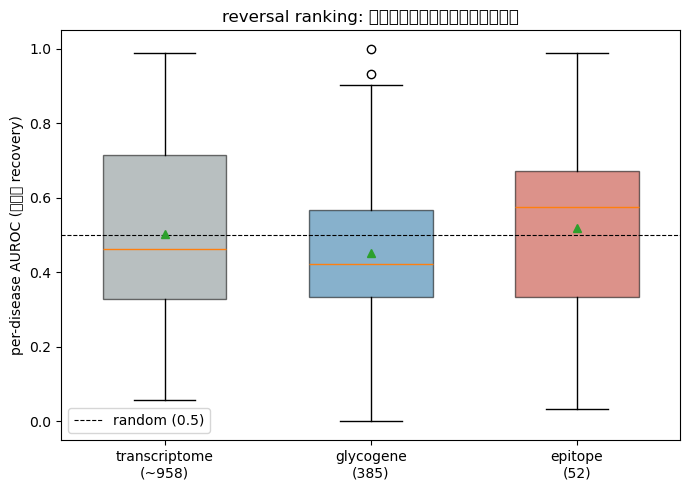

In [7]:
fig,ax=plt.subplots(figsize=(7,5))
data=[auc_tx.values, auc_gly.values, auc_ep.values]
bp=ax.boxplot(data, labels=['transcriptome\n(~958)','glycogene\n(385)','epitope\n(52)'],
              patch_artist=True, showmeans=True, widths=0.6)
for p,c in zip(bp['boxes'],['#7f8c8d','#2471a3','#c0392b']): p.set_facecolor(c); p.set_alpha(0.55)
ax.axhline(0.5,color='k',lw=0.8,ls='--',label='random (0.5)')
ax.set_ylabel('per-disease AUROC (承認薬 recovery)')
ax.set_title('reversal ranking: 承認薬をどれだけ上位にできるか'); ax.legend()
os.makedirs('../../results/figures',exist_ok=True)
fig.tight_layout(); fig.savefig('../../results/figures/reversal_ranking_benchmark.png',dpi=150,bbox_inches='tight')
plt.show()

In [8]:
os.makedirs('../../results/tables',exist_ok=True)
pd.DataFrame({'transcriptome':auc_tx,'glycogene':auc_gly,'epitope':auc_ep}).to_csv('../../results/tables/reversal_ranking_auroc.csv')
print('saved reversal_ranking_auroc.csv'); con.close()

saved reversal_ranking_auroc.csv
